# Mini - Projeto de Análise de Companhas de Marketing com Linguagem Python

## Visão do Cliente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = 'dados_marketing.csv'

In [3]:
df = pd.read_csv(file, encoding = 'utf-8', sep=';', parse_dates=['Data Cadastro'], decimal=',')

### Verificando e aumentando o número de colana visualizaveis do Data Frame

In [4]:
# Retornando o número atual de colunas exibídas
pd.get_option('display.max_columns')

20

In [5]:
# Alterando o número total de colunas exibídas
pd.set_option('display.max_columns', 50)

In [6]:
# Descubrindo o número de linhas shape[0] e o número de coluna shape[1]
df.shape

(2000, 27)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ID                              2000 non-null   int64         
 1   Ano Nascimento                  2000 non-null   int64         
 2   Escolaridade                    2000 non-null   object        
 3   Estado Civil                    2000 non-null   object        
 4   Salario Anual                   1981 non-null   float64       
 5   Filhos em Casa                  2000 non-null   int64         
 6   Adolescentes em Casa            2000 non-null   int64         
 7   Data Cadastro                   2000 non-null   datetime64[ns]
 8   Dias Desde Ultima Compra        2000 non-null   int64         
 9   Gasto com Eletronicos           2000 non-null   int64         
 10  Gasto com Brinquedos            2000 non-null   int64         
 11  Gast

In [8]:
# Verificando as 5 primeirasa linhas do DataFrame
df.head()

,ID,Ano Nascimento,Escolaridade,Estado Civil,Salario Anual,Filhos em Casa,Adolescentes em Casa,Data Cadastro,Dias Desde Ultima Compra,Gasto com Eletronicos,Gasto com Brinquedos,Gasto com Moveis,Gasto com Utilidades,Gasto com Alimentos,Gasto com Vestuario,Numero de Compras com Desconto,Numero de Compras na Web,Numero de Compras via Catalogo,Numero de Compras na Loja,Numero Visitas WebSite Mes,Compra na Campanha 1,Compra na Campanha 2,Compra na Campanha 3,Compra na Campanha 4,Compra na Campanha 5,Comprou,Pais
0,2795,1958,Mestrado,Solteiro,30523.0,2,1,2020-07-01,0,5,0,3,0,0,5,1,1,0,2,7,0,0,0,0,0,0,Chile
1,2285,1954,Mestrado,Casado,36634.0,0,1,2023-05-12,0,213,9,76,4,3,30,3,5,2,5,7,0,0,0,0,0,0,Espanha
2,115,1966,Mestrado,Solteiro,43456.0,0,1,2023-03-02,0,275,11,68,25,7,7,3,5,1,8,5,0,0,0,0,0,0,Argentina
3,10470,1979,Mestrado,Solteiro,40662.0,1,0,2023-03-05,0,40,2,23,0,4,23,2,2,1,3,4,0,0,0,0,0,0,Alemanha
4,4065,1976,Doutorado,Solteiro,49544.0,1,0,2020-02-11,0,308,0,73,0,0,23,2,5,1,8,7,0,0,0,0,0,0,Estados Unidos


### *Métricas dos clientes*

In [9]:
# Total de Cliente
total_cliente = df['ID'].nunique()
print(f"Total de Clientes = {total_cliente}")

Total de Clientes = 2000


In [10]:
# Média salárial anual dos clientes
media_salario = df['Salario Anual'].mean().round(2)
print(f"Média de Salário Anual = R$ {media_salario}")

Média de Salário Anual = R$ 52290.85


In [11]:
# Total de comprar em loja física
compra_loja = df['Numero de Compras na Loja'].sum()
print(f"Total de Compras na Loja = {compra_loja}")

Total de Compras na Loja = 11595


In [12]:
# Total de comprar na Web
compra_web = df['Numero de Compras na Web'].sum()
print(f"Total de Compras na web = {compra_web}")

Total de Compras na web = 8150


In [13]:
# Total de comprar com desconto
compra_desconto = df['Numero de Compras com Desconto'].sum()
print(f"Total de Compras com desconto = {compra_desconto}")

Total de Compras com desconto = 4665


In [14]:
# Total de comprar do via Catálogo
compra_catalogo = df['Numero de Compras via Catalogo'].sum()
print(f"Total de Compras vai Catálogo = {compra_catalogo}")

Total de Compras vai Catálogo = 5271


#### Plot da Contagem de ID por escolaridade

In [15]:
# Definindo o estilo do gráfico
sns.set_style("whitegrid")

In [16]:
# Atribuindo uma ordem decrescente para a visualização
order_by_count = df['Escolaridade'].value_counts().index

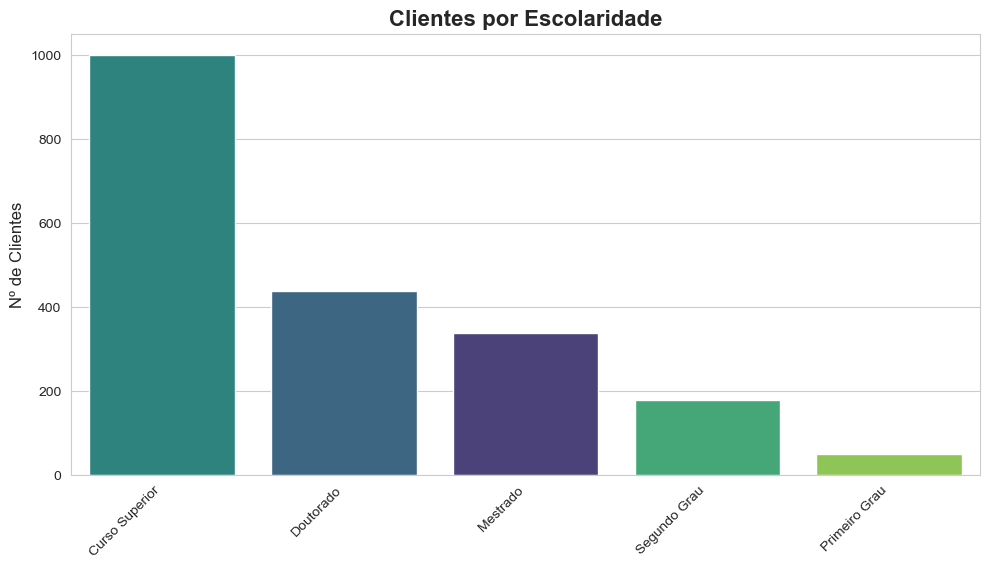

In [17]:
# Criando a figura e os eixos do Matplotlib
plt.figure(figsize=(10,6))

# Usando Seaborn para criar o gráfico de contagem
# No eixo X, vai a variável categórica 'Escolaridade'
# A função countplot() conta automaticamente as ocorrências de 'ID'
sns.countplot(x='Escolaridade', data=df, hue='Escolaridade', order= order_by_count, palette='viridis', legend=False)

# --- Adicionando os rótulos do gráfico ---

# Titulo principal do gráfico
plt.title('Clientes por Escolaridade', fontsize=16, fontweight='bold')
# Título eixo X
plt.xlabel('Escolaridade', fontsize=12)
#Título do eixo Y (o countplot() já faz a contagem, então o nome 'Número de Clientes' é apropriado
plt.ylabel('Nº de Clientes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.gca().set_xlabel(None)
plt.show()


####  Plot da Seguimentação por Estado Civíl

In [18]:
# Estilo do gráfico
sns.set_style("whitegrid")

In [19]:
# Atribuindo uma ordem decrescente para a visualização
order_by_estado = df['Estado Civil'].value_counts().index

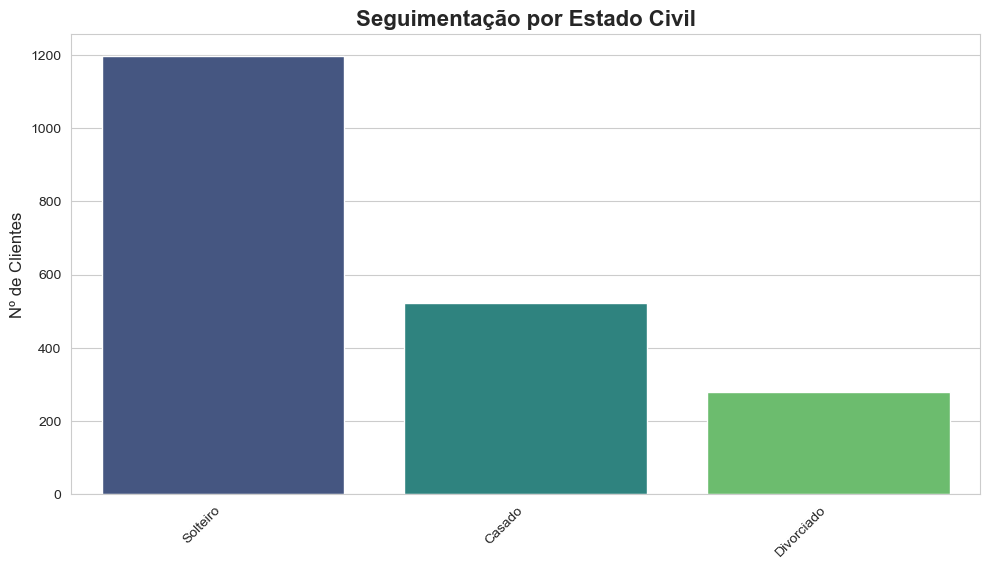

In [20]:
# Criando a figura e os eixos do Matplotlib
plt.figure(figsize=(10,6))

# Usando Seaborn para criar o gráfico de contagem
# No eixo X, vai a variável categórica 'Escolaridade'
# A função countplot() conta automaticamente as ocorrências de 'ID'
sns.countplot(x='Estado Civil', data=df, hue='Estado Civil', order= order_by_estado, palette='viridis', legend=False)

# --- Adicionando os rótulos do gráfico ---

# Titulo principal do gráfico
plt.title('Seguimentação por Estado Civil', fontsize=16, fontweight='bold')
# Título eixo X
plt.xlabel('Estado Civil', fontsize=12)
#Título do eixo Y (o countplot() já faz a contagem, então o nome 'Número de Clientes' é apropriado
plt.ylabel('Nº de Clientes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.gca().set_xlabel(None)
plt.show()

In [28]:
df.columns

Index(['ID', 'Ano Nascimento', 'Escolaridade', 'Estado Civil', 'Salario Anual',
       'Filhos em Casa', 'Adolescentes em Casa', 'Data Cadastro',
       'Dias Desde Ultima Compra', 'Gasto com Eletronicos',
       'Gasto com Brinquedos', 'Gasto com Moveis', 'Gasto com Utilidades',
       'Gasto com Alimentos', 'Gasto com Vestuario',
       'Numero de Compras com Desconto', 'Numero de Compras na Web',
       'Numero de Compras via Catalogo', 'Numero de Compras na Loja',
       'Numero Visitas WebSite Mes', 'Compra na Campanha 1',
       'Compra na Campanha 2', 'Compra na Campanha 3', 'Compra na Campanha 4',
       'Compra na Campanha 5', 'Comprou', 'Pais', 'Gasto Total'],
      dtype='object')

In [24]:
gasto_total = ['Gasto com Eletronicos', 'Gasto com Brinquedos', 'Gasto com Moveis', 'Gasto com Utilidades', 'Gasto com Alimentos','Gasto com Vestuario']

In [25]:
df['Gasto Total'] = df[gasto_total].sum(axis=1)

In [27]:
df.head()

,ID,Ano Nascimento,Escolaridade,Estado Civil,Salario Anual,Filhos em Casa,Adolescentes em Casa,Data Cadastro,Dias Desde Ultima Compra,Gasto com Eletronicos,Gasto com Brinquedos,Gasto com Moveis,Gasto com Utilidades,Gasto com Alimentos,Gasto com Vestuario,Numero de Compras com Desconto,Numero de Compras na Web,Numero de Compras via Catalogo,Numero de Compras na Loja,Numero Visitas WebSite Mes,Compra na Campanha 1,Compra na Campanha 2,Compra na Campanha 3,Compra na Campanha 4,Compra na Campanha 5,Comprou,Pais,Gasto Total
0,2795,1958,Mestrado,Solteiro,30523.0,2,1,2020-07-01,0,5,0,3,0,0,5,1,1,0,2,7,0,0,0,0,0,0,Chile,13
1,2285,1954,Mestrado,Casado,36634.0,0,1,2023-05-12,0,213,9,76,4,3,30,3,5,2,5,7,0,0,0,0,0,0,Espanha,335
2,115,1966,Mestrado,Solteiro,43456.0,0,1,2023-03-02,0,275,11,68,25,7,7,3,5,1,8,5,0,0,0,0,0,0,Argentina,393
3,10470,1979,Mestrado,Solteiro,40662.0,1,0,2023-03-05,0,40,2,23,0,4,23,2,2,1,3,4,0,0,0,0,0,0,Alemanha,92
4,4065,1976,Doutorado,Solteiro,49544.0,1,0,2020-02-11,0,308,0,73,0,0,23,2,5,1,8,7,0,0,0,0,0,0,Estados Unidos,404


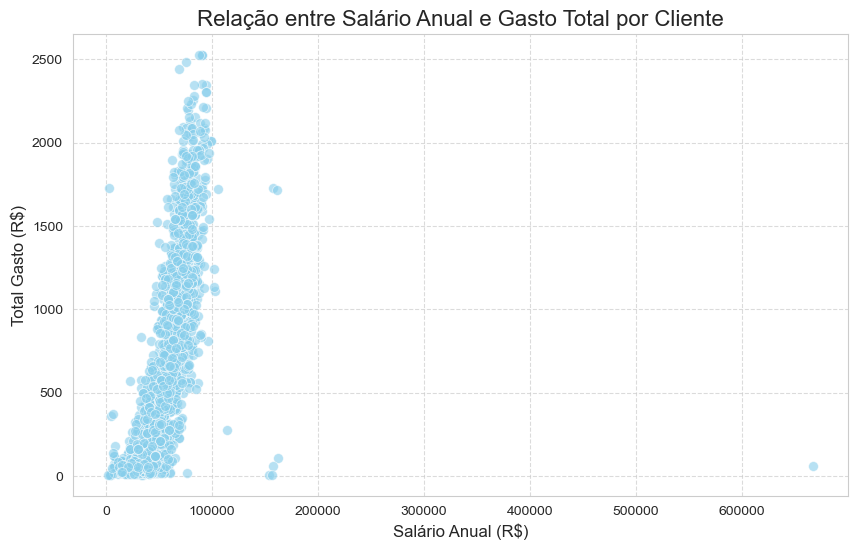

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Salario Anual',
    y='Gasto Total',
    data=df,
    color='skyblue', # Define uma cor única para todos os pontos
    s=50, # Tamanho dos Pontos
    alpha=0.6 # Transparência dos Pontos (útil para ver a densidade)
)

# Título e Rótolos

plt.title('Relação entre Salário Anual e Gasto Total por Cliente', fontsize=16)
plt.xlabel('Salário Anual (R$)', fontsize=12)
plt.ylabel('Total Gasto (R$)', fontsize=12)

# Grade

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()